In [1]:
from pathlib import Path
import sys
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

print("=" * 70)
print("BRAIN TUMOR MRI PROJECT")
print("PHASE 1 — INPUT & MRI VALIDATION")
print("=" * 70)

print("\nPython version:")
print(sys.version)

BRAIN TUMOR MRI PROJECT
PHASE 1 — INPUT & MRI VALIDATION

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
DATASET_ROOT = Path(
    r"C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)

# Handle the nested directory automatically if necessary
nested_dataset = (
    DATASET_ROOT /
    "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)

if nested_dataset.exists():
    DATASET_PATH = nested_dataset
else:
    DATASET_PATH = DATASET_ROOT

In [3]:
print("\n" + "=" * 70)
print("DATASET VALIDATION")
print("=" * 70)

print("\nDataset path:")
print(DATASET_PATH)

print("\nDataset exists:", DATASET_PATH.exists())
print("Is directory:", DATASET_PATH.is_dir())


if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"\nDataset was not found at:\n{DATASET_PATH}\n\n"
        "Please check the dataset path."
    )


DATASET VALIDATION

Dataset path:
C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData

Dataset exists: True
Is directory: True


In [4]:
cases = sorted(
    [
        p for p in DATASET_PATH.iterdir()
        if p.is_dir()
    ]
)

print("\nNumber of cases:", len(cases))

if len(cases) == 0:
    raise RuntimeError("No case directories were found.")

print("First case:", cases[0].name)


Number of cases: 1251
First case: BraTS-GLI-00000-000


In [5]:
case_dir = cases[0]

print("\n" + "=" * 70)
print("FIRST CASE")
print("=" * 70)

print("\nCase ID:")
print(case_dir.name)

print("\nCase path:")
print(case_dir)


FIRST CASE

Case ID:
BraTS-GLI-00000-000

Case path:
C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\BraTS-GLI-00000-000


In [6]:
modalities = {
    "T1": case_dir / f"{case_dir.name}-t1n.nii.gz",
    "T1c": case_dir / f"{case_dir.name}-t1c.nii.gz",
    "T2": case_dir / f"{case_dir.name}-t2w.nii.gz",
    "FLAIR": case_dir / f"{case_dir.name}-t2f.nii.gz",
    "SEG": case_dir / f"{case_dir.name}-seg.nii.gz",
}


# ================================================================
# 8. CHECK ALL REQUIRED FILES
# ================================================================

print("\n" + "=" * 70)
print("FILE VALIDATION")
print("=" * 70)

all_files_exist = True

for name, path in modalities.items():

    exists = path.exists()

    print(f"\n{name:6} : {'FOUND' if exists else 'MISSING'}")
    print("File   :", path.name)

    if not exists:
        all_files_exist = False


if not all_files_exist:
    raise FileNotFoundError(
        "\nOne or more required MRI files are missing."
    )

print("\n✓ All five required volumes were found.")



FILE VALIDATION

T1     : FOUND
File   : BraTS-GLI-00000-000-t1n.nii.gz

T1c    : FOUND
File   : BraTS-GLI-00000-000-t1c.nii.gz

T2     : FOUND
File   : BraTS-GLI-00000-000-t2w.nii.gz

FLAIR  : FOUND
File   : BraTS-GLI-00000-000-t2f.nii.gz

SEG    : FOUND
File   : BraTS-GLI-00000-000-seg.nii.gz

✓ All five required volumes were found.


In [7]:
print("\n" + "=" * 70)
print("LOADING NIFTI VOLUMES")
print("=" * 70)

images = {}
nifti_objects = {}

for name, path in modalities.items():

    try:

        img = nib.load(str(path))

        # get_fdata() gives floating-point data
        data = img.get_fdata()

        nifti_objects[name] = img
        images[name] = data

        print(f"\n✓ {name} loaded successfully")
        print("  Shape :", data.shape)

    except Exception as e:

        print(f"\n✗ Failed to load {name}")
        print("  Error:", e)

        raise


print("\n✓ All five volumes loaded successfully.")



LOADING NIFTI VOLUMES

✓ T1 loaded successfully
  Shape : (240, 240, 155)

✓ T1c loaded successfully
  Shape : (240, 240, 155)

✓ T2 loaded successfully
  Shape : (240, 240, 155)

✓ FLAIR loaded successfully
  Shape : (240, 240, 155)

✓ SEG loaded successfully
  Shape : (240, 240, 155)

✓ All five volumes loaded successfully.


In [8]:
print("\n" + "=" * 70)
print("MRI VOLUME INFORMATION")
print("=" * 70)

for name, img in nifti_objects.items():

    data = images[name]

    spacing = img.header.get_zooms()[:3]

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    print("File:")
    print(" ", modalities[name].name)

    print("Shape:")
    print(" ", data.shape)

    print("Voxel spacing:")
    print(" ", tuple(float(x) for x in spacing))

    print("Data type:")
    print(" ", data.dtype)

    print("Minimum:")
    print(" ", float(np.min(data)))

    print("Maximum:")
    print(" ", float(np.max(data)))

    print("Mean:")
    print(" ", float(np.mean(data)))

    print("Standard deviation:")
    print(" ", float(np.std(data)))

    non_zero = np.count_nonzero(data)

    print("Non-zero voxels:")
    print(" ", int(non_zero))

    print("Total voxels:")
    print(" ", int(data.size))

    print("Non-zero percentage:")
    print(" ", round((non_zero / data.size) * 100, 4), "%")


MRI VOLUME INFORMATION

----------------------------------------------------------------------
T1
----------------------------------------------------------------------
File:
  BraTS-GLI-00000-000-t1n.nii.gz
Shape:
  (240, 240, 155)
Voxel spacing:
  (1.0, 1.0, 1.0)
Data type:
  float64
Minimum:
  0.0
Maximum:
  2023.0
Mean:
  132.99798633512546
Standard deviation:
  306.4174998580979
Non-zero voxels:
  1480170
Total voxels:
  8928000
Non-zero percentage:
  16.579 %

----------------------------------------------------------------------
T1c
----------------------------------------------------------------------
File:
  BraTS-GLI-00000-000-t1c.nii.gz
Shape:
  (240, 240, 155)
Voxel spacing:
  (1.0, 1.0, 1.0)
Data type:
  float64
Minimum:
  0.0
Maximum:
  12343.0
Mean:
  345.5059033378136
Standard deviation:
  846.7899620988591
Non-zero voxels:
  1480170
Total voxels:
  8928000
Non-zero percentage:
  16.579 %

----------------------------------------------------------------------
T2
------


AFFINE & ORIENTATION

----------------------------------------------------------------------
T1
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
T1c
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
T2
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
FLAIR
-----------------------------------------

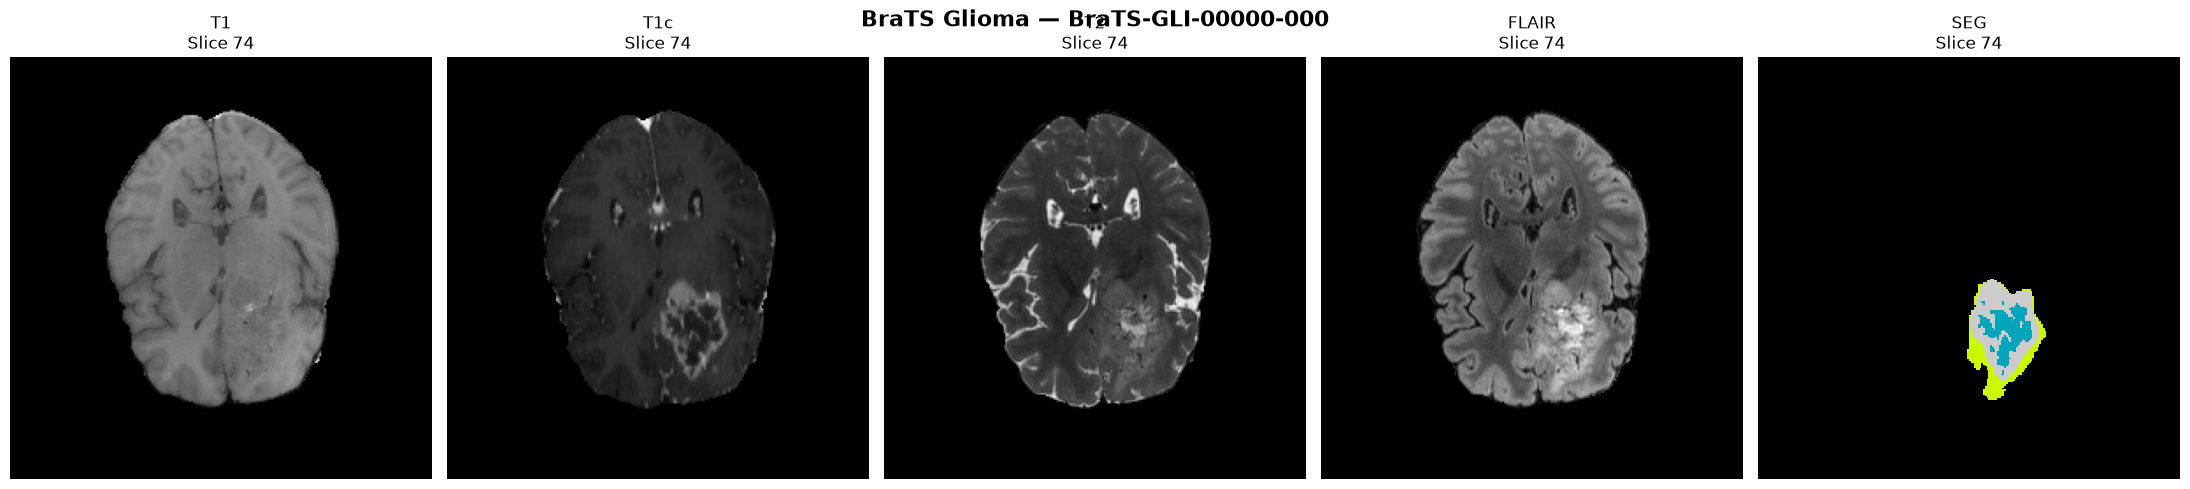

Creating tumor overlay...


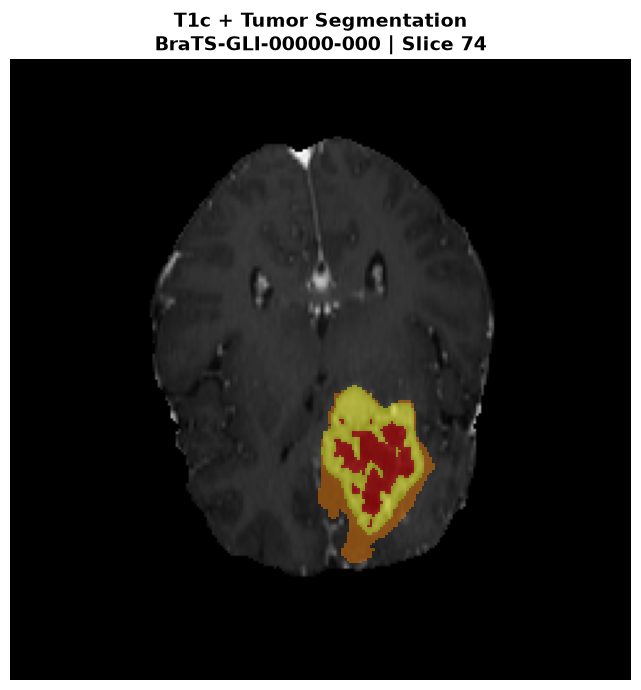


FINAL VALIDATION SUMMARY

Dataset:
  C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData

Number of cases:
  1251

Case inspected:
  BraTS-GLI-00000-000

Required modalities:
  ['T1', 'T1c', 'T2', 'FLAIR', 'SEG']

All files found:
  YES

All volumes loaded:
  YES

Shape consistent:
  YES

Spacing consistent:
  YES

Image/SEG shape compatible:
  YES

Tumor present:
  YES

Selected visualization slice:
  74

PHASE 1 MRI VALIDATION COMPLETE FOR THIS CASE

Next stage:
  Orientation verification
  → Resampling
  → Intensity normalization
  → Cropping
  → Patch extraction


In [10]:
# ================================================================
# 11. AFFINE AND ORIENTATION INFORMATION
# ================================================================

print("\n" + "=" * 70)
print("AFFINE & ORIENTATION")
print("=" * 70)

for name, img in nifti_objects.items():

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    print("Affine matrix:")
    print(img.affine)

    orientation = nib.aff2axcodes(img.affine)

    print("\nOrientation:")
    print(" ", orientation)



AFFINE & ORIENTATION

----------------------------------------------------------------------
T1
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
T1c
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
T2
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
FLAIR
-----------------------------------------

In [11]:
# ================================================================
# 12. CHECK IMAGE SPACING CONSISTENCY
# ================================================================

print("\n" + "=" * 70)
print("SPACING CONSISTENCY CHECK")
print("=" * 70)

reference_spacing = (
    nifti_objects["T1"]
    .header
    .get_zooms()[:3]
)

print("\nReference spacing (T1):")
print(tuple(float(x) for x in reference_spacing))

spacing_consistent = True

for name, img in nifti_objects.items():

    spacing = img.header.get_zooms()[:3]

    same = np.allclose(
        spacing,
        reference_spacing
    )

    print(
        f"{name:6}: "
        f"{'MATCH' if same else 'DIFFERENT'} "
        f"{tuple(float(x) for x in spacing)}"
    )

    if not same:
        spacing_consistent = False


if spacing_consistent:
    print("\n✓ All five volumes have consistent voxel spacing.")
else:
    print("\n⚠ Some volumes have different voxel spacing.")



SPACING CONSISTENCY CHECK

Reference spacing (T1):
(1.0, 1.0, 1.0)
T1    : MATCH (1.0, 1.0, 1.0)
T1c   : MATCH (1.0, 1.0, 1.0)
T2    : MATCH (1.0, 1.0, 1.0)
FLAIR : MATCH (1.0, 1.0, 1.0)
SEG   : MATCH (1.0, 1.0, 1.0)

✓ All five volumes have consistent voxel spacing.


In [12]:
# ================================================================
# 13. CHECK SHAPE CONSISTENCY
# ================================================================

print("\n" + "=" * 70)
print("SHAPE CONSISTENCY CHECK")
print("=" * 70)

reference_shape = images["T1"].shape

print("\nReference shape (T1):")
print(reference_shape)

shape_consistent = True

for name, data in images.items():

    same = data.shape == reference_shape

    print(
        f"{name:6}: "
        f"{'MATCH' if same else 'DIFFERENT'} "
        f"{data.shape}"
    )

    if not same:
        shape_consistent = False


if shape_consistent:
    print("\n✓ All five volumes have identical dimensions.")
else:
    print("\n⚠ Some volumes have different dimensions.")



SHAPE CONSISTENCY CHECK

Reference shape (T1):
(240, 240, 155)
T1    : MATCH (240, 240, 155)
T1c   : MATCH (240, 240, 155)
T2    : MATCH (240, 240, 155)
FLAIR : MATCH (240, 240, 155)
SEG   : MATCH (240, 240, 155)

✓ All five volumes have identical dimensions.


In [13]:
# ================================================================
# 15. SEGMENTATION LABEL ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("SEGMENTATION LABEL ANALYSIS")
print("=" * 70)

# Segmentation masks should contain discrete labels
seg_unique, seg_counts = np.unique(
    seg_data,
    return_counts=True
)

print("\nUnique segmentation values:")

for value, count in zip(seg_unique, seg_counts):

    percentage = (
        count / seg_data.size
    ) * 100

    print(
        f"Label {value:g} : "
        f"{int(count):,} voxels "
        f"({percentage:.4f}%)"
    )



SEGMENTATION LABEL ANALYSIS

Unique segmentation values:
Label 0 : 8,870,695 voxels (99.3581%)
Label 1 : 11,738 voxels (0.1315%)
Label 2 : 12,836 voxels (0.1438%)
Label 3 : 32,731 voxels (0.3666%)


In [14]:
# ================================================================
# 16. TUMOR VOXEL CHECK
# ================================================================

tumor_mask = seg_data > 0

tumor_voxels = int(np.count_nonzero(tumor_mask))
total_voxels = int(seg_data.size)

print("\nTumor voxels:")
print(tumor_voxels)

print("\nTumor voxel percentage:")
print(
    round(
        (tumor_voxels / total_voxels) * 100,
        4
    ),
    "%"
)

if tumor_voxels > 0:
    print("\n✓ Tumor is present in the segmentation mask.")
else:
    print("\n⚠ No tumor voxels found in this case.")



Tumor voxels:
57305

Tumor voxel percentage:
0.6419 %

✓ Tumor is present in the segmentation mask.


In [15]:
print("\n" + "=" * 70)
print("TUMOR BOUNDING BOX")
print("=" * 70)

if tumor_voxels > 0:

    tumor_indices = np.argwhere(tumor_mask)

    min_coords = tumor_indices.min(axis=0)
    max_coords = tumor_indices.max(axis=0)

    print("\nMinimum voxel coordinates:")
    print(tuple(int(x) for x in min_coords))

    print("\nMaximum voxel coordinates:")
    print(tuple(int(x) for x in max_coords))

    tumor_size = max_coords - min_coords + 1

    print("\nTumor bounding-box size:")
    print(tuple(int(x) for x in tumor_size))

else:

    print("\nNo tumor bounding box available.")



TUMOR BOUNDING BOX

Minimum voxel coordinates:
(118, 45, 49)

Maximum voxel coordinates:
(163, 120, 95)

Tumor bounding-box size:
(46, 76, 47)


In [16]:

if tumor_voxels > 0:

    tumor_per_slice = tumor_mask.sum(
        axis=(0, 1)
    )

    best_slice = int(
        np.argmax(tumor_per_slice)
    )

else:

    best_slice = images["T1"].shape[2] // 2


print("\n" + "=" * 70)
print("VISUALIZATION SLICE")
print("=" * 70)

print("\nSelected axial slice:")
print(best_slice)


VISUALIZATION SLICE

Selected axial slice:
74



Creating MRI visualization...


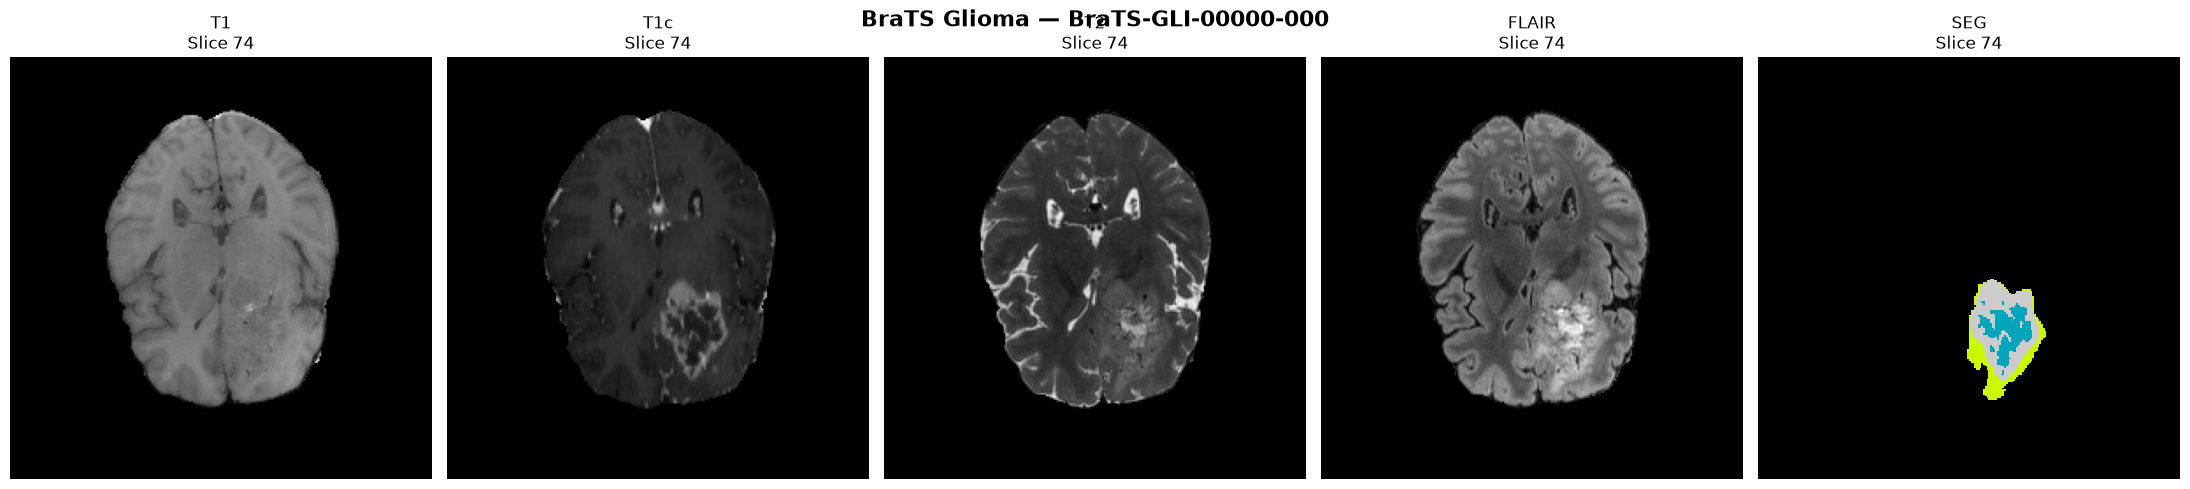

In [17]:
# ================================================================
# 19. VISUALIZE ALL FOUR MRI MODALITIES
# ================================================================

print("\nCreating MRI visualization...")

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

display_modalities = [
    "T1",
    "T1c",
    "T2",
    "FLAIR",
    "SEG"
]

for ax, name in zip(axes, display_modalities):

    data = images[name]

    if name == "SEG":

        ax.imshow(
            np.rot90(data[:, :, best_slice]),
            cmap="nipy_spectral",
            interpolation="nearest"
        )

        ax.set_title(
            f"{name}\nSlice {best_slice}"
        )

    else:

        ax.imshow(
            np.rot90(data[:, :, best_slice]),
            cmap="gray"
        )

        ax.set_title(
            f"{name}\nSlice {best_slice}"
        )

    ax.axis("off")


plt.suptitle(
    f"BraTS Glioma — {case_dir.name}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


Creating tumor overlay...


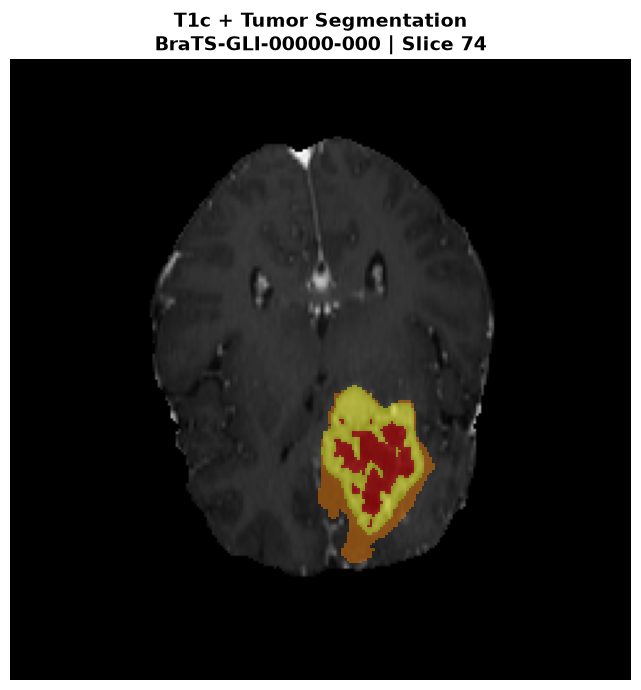

In [18]:
# ================================================================
# 20. MRI + SEGMENTATION OVERLAY
# ================================================================

print("Creating tumor overlay...")

fig, ax = plt.subplots(
    figsize=(7, 7)
)

# MRI background
ax.imshow(
    np.rot90(images["T1c"][:, :, best_slice]),
    cmap="gray"
)

# Segmentation overlay
seg_slice = np.rot90(
    seg_data[:, :, best_slice]
)

masked_seg = np.ma.masked_where(
    seg_slice == 0,
    seg_slice
)

ax.imshow(
    masked_seg,
    cmap="autumn",
    alpha=0.45,
    interpolation="nearest"
)

ax.set_title(
    f"T1c + Tumor Segmentation\n"
    f"{case_dir.name} | Slice {best_slice}",
    fontsize=14,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()



In [19]:
# ================================================================
# 21. FINAL VALIDATION SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION SUMMARY")
print("=" * 70)

print("\nDataset:")
print(" ", DATASET_PATH)

print("\nNumber of cases:")
print(" ", len(cases))

print("\nCase inspected:")
print(" ", case_dir.name)

print("\nRequired modalities:")
print(" ", list(modalities.keys()))

print("\nAll files found:")
print(" ", "YES" if all_files_exist else "NO")

print("\nAll volumes loaded:")
print(" ", "YES")

print("\nShape consistent:")
print(" ", "YES" if shape_consistent else "NO")

print("\nSpacing consistent:")
print(" ", "YES" if spacing_consistent else "NO")

print("\nImage/SEG shape compatible:")
print(
    " ",
    "YES"
    if images["T1"].shape == seg_data.shape
    else "NO"
)

print("\nTumor present:")
print(
    " ",
    "YES"
    if tumor_voxels > 0
    else "NO"
)

print("\nSelected visualization slice:")
print(" ", best_slice)

print("\n" + "=" * 70)
print("PHASE 1 MRI VALIDATION COMPLETE FOR THIS CASE")
print("=" * 70)

print(
    "\nNext stage:"
    "\n  Orientation verification"
    "\n  → Resampling"
    "\n  → Intensity normalization"
    "\n  → Cropping"
    "\n  → Patch extraction"
)


FINAL VALIDATION SUMMARY

Dataset:
  C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData

Number of cases:
  1251

Case inspected:
  BraTS-GLI-00000-000

Required modalities:
  ['T1', 'T1c', 'T2', 'FLAIR', 'SEG']

All files found:
  YES

All volumes loaded:
  YES

Shape consistent:
  YES

Spacing consistent:
  YES

Image/SEG shape compatible:
  YES

Tumor present:
  YES

Selected visualization slice:
  74

PHASE 1 MRI VALIDATION COMPLETE FOR THIS CASE

Next stage:
  Orientation verification
  → Resampling
  → Intensity normalization
  → Cropping
  → Patch extraction
